In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [56]:
df = pd.read_csv('train.csv')

In [57]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Объем памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Размер датасета: 22730 строк, 18 столбцов
Объем памяти: 3.12 MB


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22730 entries, 0 to 22729
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 22730 non-null  int64  
 1   squareMeters       22730 non-null  int64  
 2   numberOfRooms      22730 non-null  int64  
 3   hasYard            22730 non-null  int64  
 4   hasPool            22730 non-null  int64  
 5   floors             22730 non-null  int64  
 6   cityCode           22730 non-null  int64  
 7   cityPartRange      22730 non-null  int64  
 8   numPrevOwners      22730 non-null  int64  
 9   made               22730 non-null  int64  
 10  isNewBuilt         22730 non-null  int64  
 11  hasStormProtector  22730 non-null  int64  
 12  basement           22730 non-null  int64  
 13  attic              22730 non-null  int64  
 14  garage             22730 non-null  int64  
 15  hasStorageRoom     22730 non-null  int64  
 16  hasGuestRoom       227

In [59]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
interval_stats = df[numeric_cols].describe(percentiles=[.25, .75]).T[['min', '50%', 'mean', 'max', '25%', '75%']]
interval_stats.rename(columns={'50%': 'median'}, inplace=True)
print("\nСтатистика интервальных переменных:")
display(interval_stats)


Статистика интервальных переменных:


,min,median,mean,max,25%,75%
id,0.0,11364.5,1.136450e+04,22729.0,5682.25,17046.75
squareMeters,89.0,44484.0,4.658622e+04,6071330.0,20392.75,71547.00
numberOfRooms,1.0,47.0,4.824109e+01,100.0,25.00,75.00
hasYard,0.0,0.0,4.758909e-01,1.0,0.00,1.00
hasPool,0.0,0.0,4.527497e-01,1.0,0.00,1.00
floors,1.0,45.0,4.730598e+01,6000.0,25.00,69.00
cityCode,3.0,50414.0,5.001380e+04,491100.0,22936.00,76291.00
cityPartRange,1.0,6.0,5.585042e+00,10.0,3.00,8.00
numPrevOwners,1.0,6.0,5.620766e+00,10.0,3.00,8.00
made,1990.0,2006.0,2.008005e+03,10000.0,2000.00,2014.00


In [60]:
#я бы применил что-то в таком духе, если бы были категориальные признаки

#cat_cols = df.select_dtypes(include=['object']).columns
# for col in cat_cols:
#     mode_val = df[col].mode()[0]
#     mode_freq = df[col].value_counts().iloc[0]
#     print(f"Категория '{col}': Мода = {mode_val}, Частота = {mode_freq}")

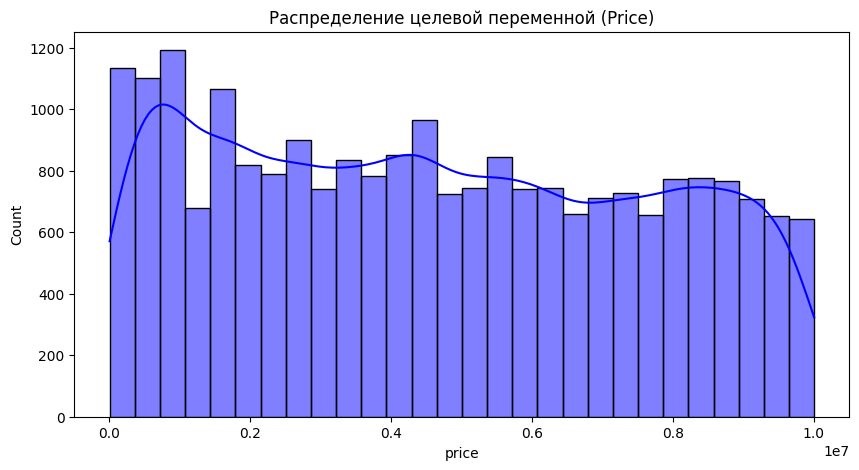

In [61]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Распределение целевой переменной (Price)')
plt.show()

<Axes: ylabel='price'>

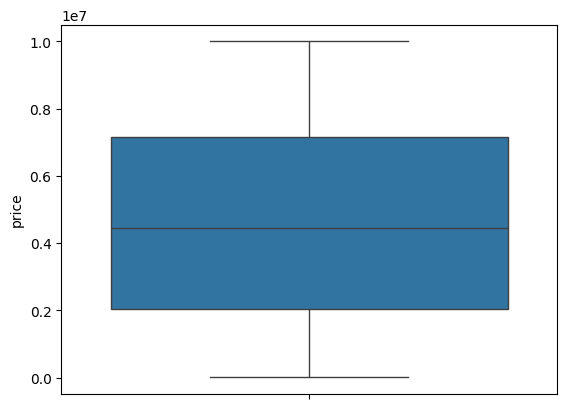

In [63]:
sns.boxplot(df['price'])

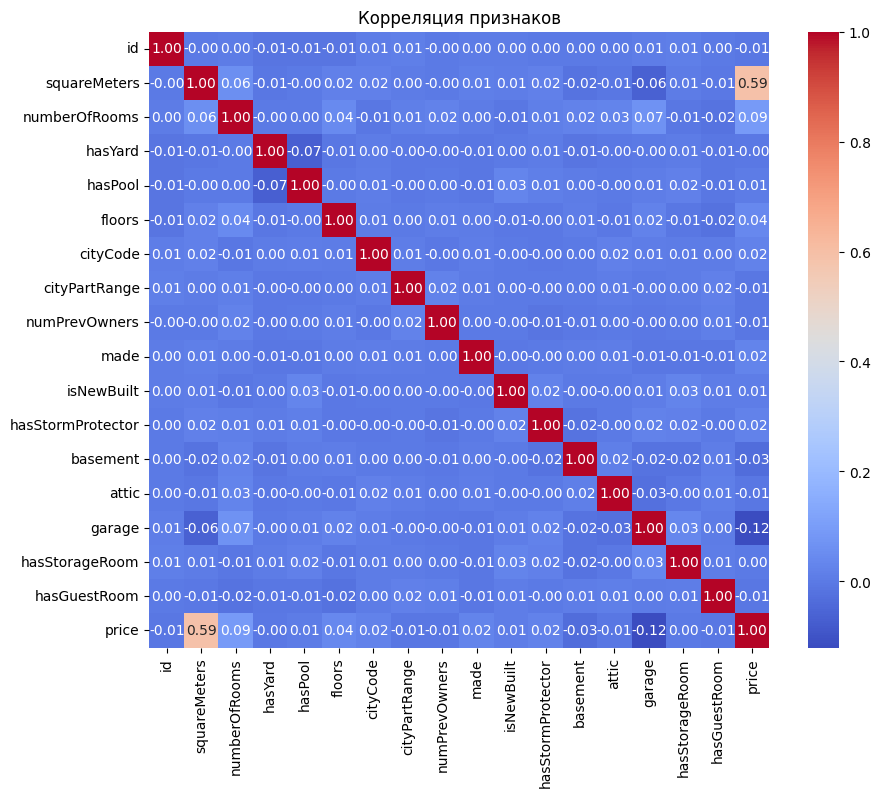

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

In [64]:
class NaNFiller:
    def __call__(self, df, fillable, option='mode'):
        for col in fillable:
            if option == 'mode':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].mean())
        return df

In [65]:
filler = NaNFiller()
df = filler(df, numeric_cols, option='mean')
# df = filler(df, cat_cols, option='mode')

In [66]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 * IQR)))]

In [46]:
#я бы сделал это, но у меня нету категориальных данных в датасете
# encoder = OneHotEncoder(sparse_output=False, drop='first')
# encoded_data = encoder.fit_transform(df[cat_cols])
# df_encoded = pd.concat([df.drop(cat_cols, axis=1), 
#                         pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(), index=df.index)], axis=1)

In [47]:
X = df.drop('price', axis=1)
y = df['price']

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [50]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=7)
}
results = {}

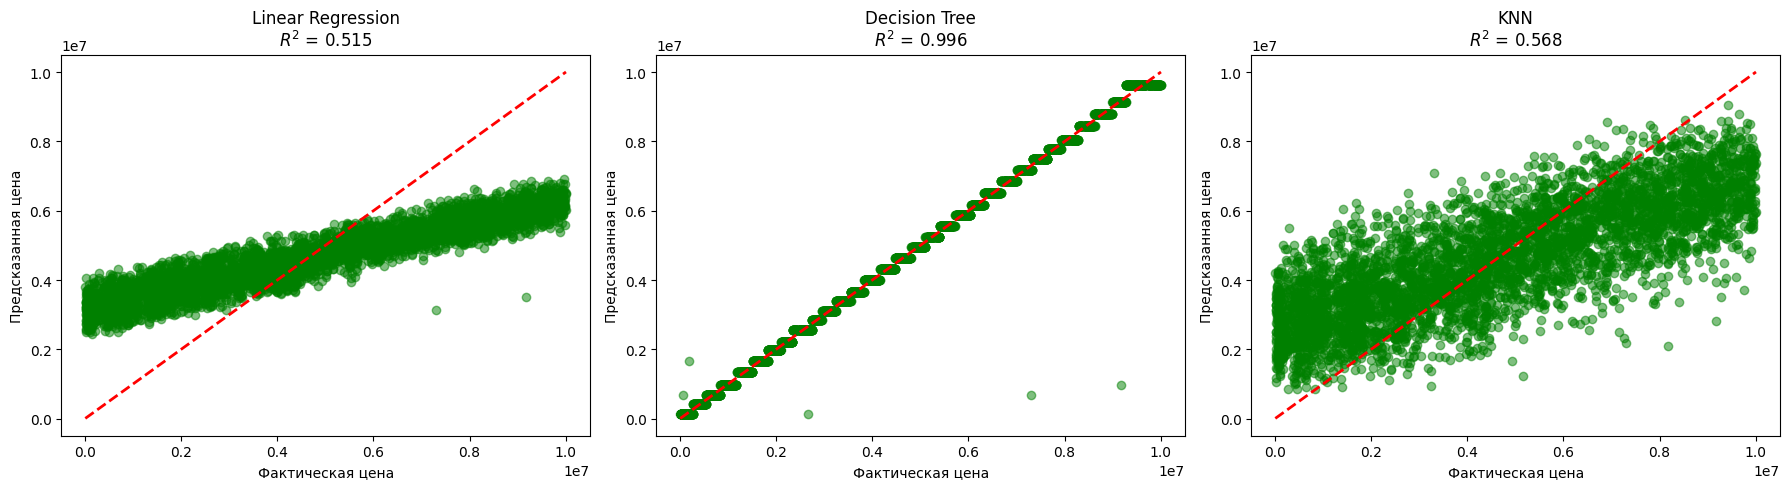

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"MAE": mae, "MSE": mse, "R2": r2}
    
    axes[i].scatter(y_test, preds, alpha=0.5, color='green')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(f"{name}\n$R^2$ = {r2:.3f}")
    axes[i].set_xlabel("Фактическая цена")
    axes[i].set_ylabel("Предсказанная цена")

plt.tight_layout()
plt.show()

In [52]:
res_df = pd.DataFrame(results).T
print("\nСводная таблица метрик:")
display(res_df.sort_values(by='R2', ascending=False))

best_model_name = res_df['R2'].idxmax()
print(f"Лучшая модель по метрике R^2: {best_model_name}")


Сводная таблица метрик:


,MAE,MSE,R2
Decision Tree,8.847628e+04,3.702556e+10,0.995716
KNN,1.595101e+06,3.730724e+12,0.568326
Linear Regression,1.756174e+06,4.189365e+12,0.515257


Лучшая модель по метрике R^2: Decision Tree
